In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [6]:
#----------------------------------
# LOAD + PREPROCESS

df = pd.read_csv("../data/df_filtered.csv")

# pathway per locus
def get_mode(x):
    m = x.mode()
    if len(m) > 1:
        print("AMBIGUOUS LOCUS:", x.name, list(m))
    return m[0]

locus_pathway = df.groupby("locus")["SQ_pathway"].agg(get_mode)

# counts: locus × order 
heatmap_df = (
    df.groupby(["locus", "order"])
    .size()
    .unstack(fill_value=0)
)

# sort orders by abundance
heatmap_df = heatmap_df[
    heatmap_df.sum(axis=0).sort_values(ascending=False).index
]

AMBIGUOUS LOCUS: SQ_pathway ['sulfo-TAL', 'sulfo-TK']


In [7]:
#----------------------------------
# FUNCTION: PLOT HEATMAP
def plot_heatmap(data, pathway_labels, filename):
    
    # COLORS
    pathway_colors = {
        'sulfo-EMP': '#2CAEA1',
        'sulfo-TAL': '#df81b5',
        'sulfo-TK': '#993399',
    }

    row_colors = pathway_labels.map(pathway_colors)
    row_colors.name = None

    # HEATMAP (cluster map version)
    g = sns.clustermap(
        data,
        row_cluster=False,
        col_cluster=False,
        row_colors=row_colors,
        cmap="Blues",
        linewidths=0.2,
        figsize=(10, 8),
        cbar_kws={"label": "Value"},
        cbar_pos=(0.05, 0.25, 0.02, 0.4)
    )
    
    # AXIS LABELS + FONTS
    g.ax_heatmap.set_xlabel("Order", fontsize=14)
    g.ax_heatmap.set_ylabel("Gene set", fontsize=14)

    g.ax_heatmap.tick_params(axis='x', labelsize=14, rotation=45)
    g.ax_heatmap.tick_params(axis='y', labelsize=14)

    plt.setp(g.ax_heatmap.get_xticklabels(),
            rotation=45, ha="right", fontsize=12)

    plt.setp(g.ax_heatmap.get_yticklabels(), fontsize=12)

    # LEGEND
    for name, color in pathway_colors.items():
        g.ax_heatmap.scatter([], [], color=color, label=name)

    g.ax_heatmap.legend(
        title="Pathway",
        bbox_to_anchor=(-0.35, 1),
        loc="upper left",
        fontsize=12
    )
    # SAVE
    plt.savefig(filename, dpi=300, bbox_inches="tight")



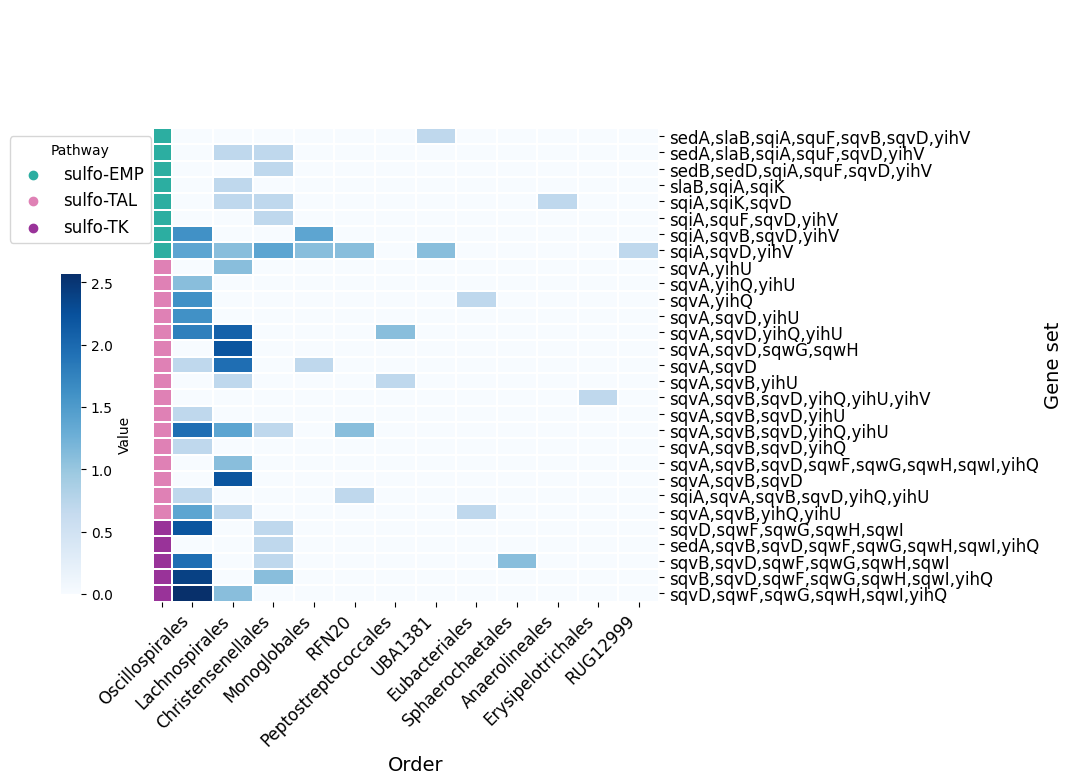

In [8]:
#----------------------------------
# RAW + LOG HEATMAP

heatmap_df["pathway"] = heatmap_df.index.map(locus_pathway)
heatmap_df = heatmap_df.sort_values("pathway")

pathway_labels = heatmap_df["pathway"]
heatmap_df = heatmap_df.drop(columns="pathway")

heatmap_log = np.log1p(heatmap_df)

plot_heatmap(
    heatmap_log,
    pathway_labels,
    "../pictures/loci/loci_log.png"
)

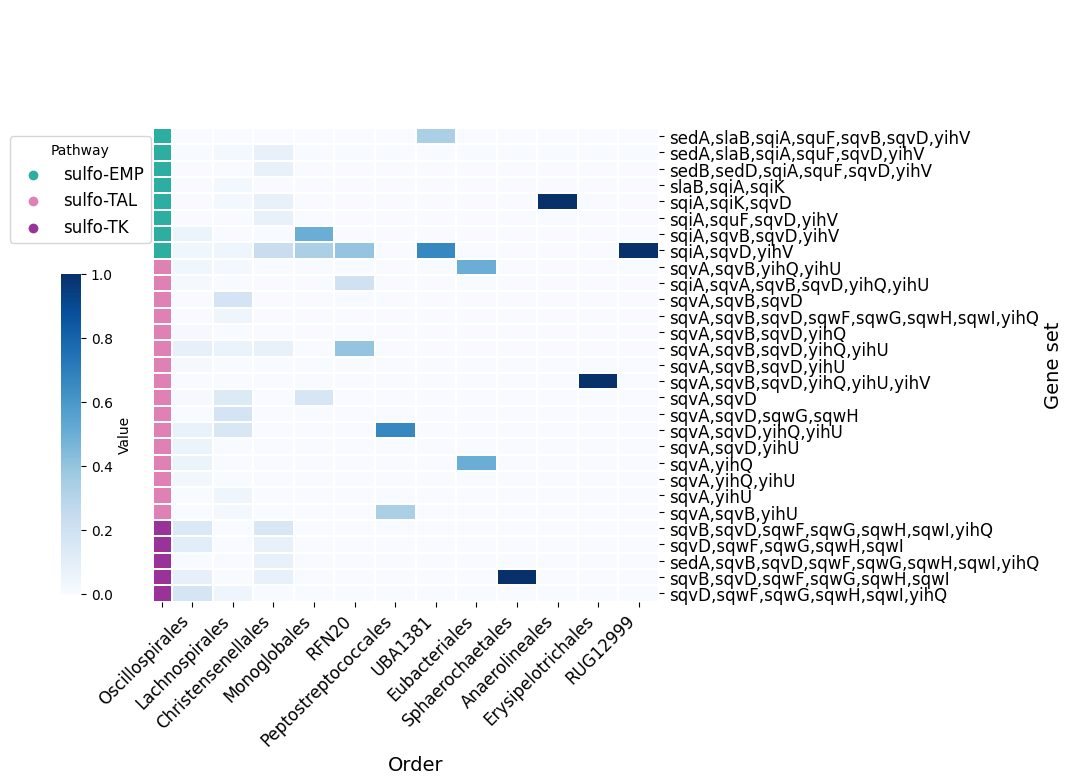

In [9]:
#----------------------------------
# NORMALIZED HEATMAP

order_sizes = heatmap_df.sum(axis=0).replace(0, np.nan)

heatmap_norm = heatmap_df.div(order_sizes, axis=1).fillna(0)

# sort by pathway
heatmap_norm["pathway"] = heatmap_norm.index.map(locus_pathway)
heatmap_norm = heatmap_norm.sort_values("pathway")

pathway_labels_norm = heatmap_norm["pathway"]
heatmap_norm = heatmap_norm.drop(columns="pathway")

plot_heatmap(
    heatmap_norm,
    pathway_labels_norm,
    "../pictures/loci/loci_normalized.png"
)